In [1]:
from compute_cm_rate import *
from proba_scw import *
from plots import *
import itertools

In [2]:
compute_cm_rate_of_n_v_n_c_joblib(
    compute_cm_rate=irv_cm_rate, 
    n_vs=[10, 30, 100, 300, 1000], 
    n_cs=range(3, 11),
    n_samples=100000
)
'4h24m35s'

In [3]:
my_magic_load(locals())

In [4]:
d_m_p_stderr = compute_irv_cm_over_m(range(3, 11), n_samples=1_000_000, seed=42, batch=50_000)
d_m_p_stderr

OrderedDict([(3, (0.16882000000000008, 0.0013426391203893919)),
             (4, (0.347156, 0.0014782322928633376)),
             (5, (0.498575, 0.001501898122169077)),
             (6, (0.62185, 0.0014580475223736709)),
             (7, (0.715569, 0.001382069465055574)),
             (8, (0.7850159999999999, 0.0012936977544016994)),
             (9, (0.838144, 0.0011960378903964539)),
             (10, (0.87949, 0.0010911358026845237))])

In [19]:
tex = latex_table_irv_cm(d_m_p_stderr, digits=4)
print(tex)

\begin{tabular}{r r}
\toprule
$m$ & $\Pr[\text{IRV is CM}]$ \\
\midrule
3 & $0.1688 \pm 0.0013$ \\
4 & $0.3472 \pm 0.0015$ \\
5 & $0.4986 \pm 0.0015$ \\
6 & $0.6219 \pm 0.0015$ \\
7 & $0.7156 \pm 0.0014$ \\
8 & $0.7850 \pm 0.0013$ \\
9 & $0.8381 \pm 0.0012$ \\
10 & $0.8795 \pm 0.0011$ \\
\bottomrule
\end{tabular}


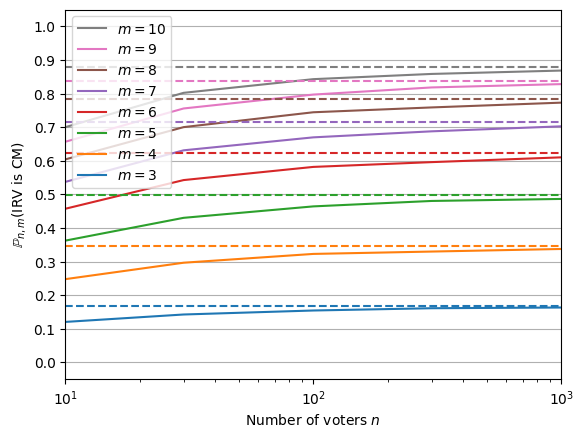

In [39]:
plot_cm_rate_of_n_v_n_c(
    cm_rates, n_vs=n_vs, n_cs=n_cs,
    rule_name='IRV', 
    invert_legend_order=True,
    d_m_p_stderr=d_m_p_stderr,
)

Let us try to push the code further. As illustrated below, the dimensionality of the $H$ matrix becomes too large for $m \geq 16$.

In [41]:
for m in range(2, 20):
    x = probability_irv_is_cm(m, n_samples=1_000_000, seed=42, batch=50_000)
    print(f"{m=}, {x=}")

m=2, x=(0.0, 0.001)
m=3, x=(0.16882000000000008, 0.0013426391203893919)
m=4, x=(0.347156, 0.0014782322928633376)
m=5, x=(0.498575, 0.001501898122169077)
m=6, x=(0.62185, 0.0014580475223736709)
m=7, x=(0.715569, 0.001382069465055574)
m=8, x=(0.7850159999999999, 0.0012936977544016994)
m=9, x=(0.838144, 0.0011960378903964539)
m=10, x=(0.87949, 0.0010911358026845237)
m=11, x=(0.910515, 0.000988092827003111)
m=12, x=(0.932836, 0.0008952413066341388)
m=13, x=(0.950041, 0.0008043451363183592)
m=14, x=(0.9619759999999999, 0.0007286221074219475)
m=15, x=(0.972655, 0.0006398650255913351)


ValueError: Maximum supported dimensionality is 21201.